# Consigna

????

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''
        noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Genera ruido gaussiano con varianza var.

        Nota: El ruido blanco se define como normal o gaussiano, con media 0 y con una varianza igual a la potencia de ruido
        (Extraido de apuntes de ASYS de procesos estocásticos, "ruido blanco")
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=var, size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
    var_noise = ((vmax**2)/2) / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))


# Respuesta

In [91]:
import numpy as np

def my_DFT(xx: np.ndarray ) -> np.ndarray:
    '''
    my_DFT calcula la DFT (Transformada de Fourier Digital) por definición

    xx: Vector de numpy. Se recomienda tener la forma (N x 1).

    return value:
    vector complejo con la transformada de Fourier. Tiene la forma (N x 1). 
    '''
    N = max(np.shape(xx))
    n = np.arange(N).reshape(-1,1)  # (-1,1) == (N,1) Truquito de python
    k = n.copy().reshape(1,-1)
    e_table = np.exp(-1j*2*np.pi*n*k/N)
    # Realiza la tabla de exponenciales partiendo de 2 vectores (uno fila y otro columna) n y k. Genera una malla de valores:
    #    [0][1][2]  k->
    # [0]|---------| 
    # [1]|         |
    # [2]|---------|
    #  n

    xx = xx.reshape(-1,1)   # Por seguridad
    x_k = np.dot(e_table, xx)

    #for k in range(N):
    #	aux = 0
    #	for x in range(xx):
    #		aux = aux + x (np.cos(-1j*2*np.pi * x *k/N))
    #		# aux = aux + x * np.e **(-1j*2*np.pi * x * k/N)
    #	x_k.append(aux)
    
    return x_k



## Resolución Genérica

In [92]:
import time

##### Variables
N = 8
n = np.arange(N).reshape(1,-1)

##### Funcion
xx = np.sin(2*np.pi*n/N + np.deg2rad(0))
xx = np.array(xx).reshape(-1,1)


##### Calculo de FFT
inicio = time.perf_counter()
x_k = my_DFT(xx)
med = time.perf_counter()
x_k_fft = np.fft.fft(xx, axis=0)
fin = time.perf_counter()

print(f"tiempo dft: {med-inicio}")
print(f"tiempo fft: {fin-med}")
print(f"La FFT es {(med-inicio)/(fin-med)} veces más rápido")
# La diferencia se observa en valores grandes de N.
# La FFT es un algoritmo que funciona con potencias de 2 como valor de N. 
# Para evitar realizar padding, se recomienda una cantidad correcta

tiempo dft: 0.000316200000270328
tiempo fft: 0.00025629999981902074
La FFT es 1.2337104974389546 veces más rápido


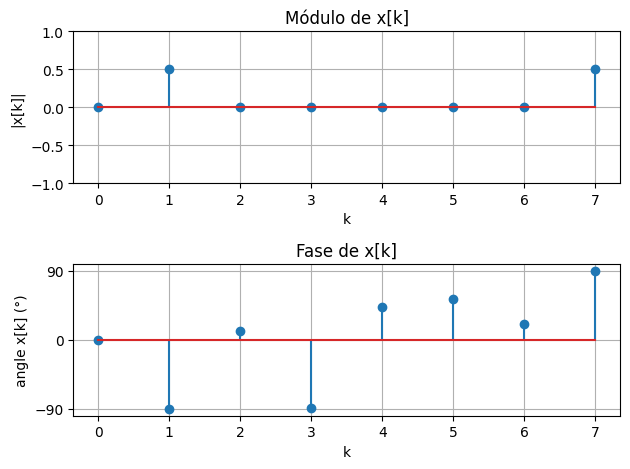

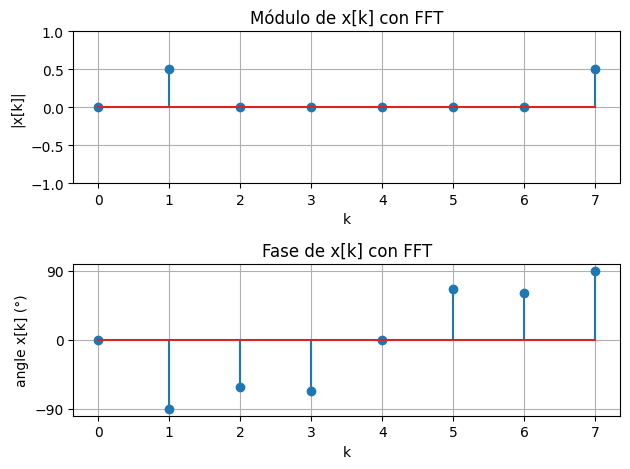

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Módulo y fase ########################################
modulo = np.abs(x_k)
fase = np.angle(x_k)
modulo_fft = np.abs(x_k_fft)
fase_fft = np.angle(x_k_fft)

# Gráficas my_DFT ########################################
plt.figure()

# Módulo
plt.subplot(2, 1, 1)
plt.stem(modulo/N)
plt.title("Módulo de x[k]")
plt.xlabel("k")
plt.yticks([-1, -.5, 0, .5, 1])
plt.ylabel("|x[k]|")
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.title("Fase de x[k]")
plt.stem( np.rad2deg(fase))
plt.xlabel("k")
plt.ylabel("angle x[k] (°)")
plt.yticks([-90, 0, 90])
plt.grid()

plt.tight_layout()
plt.show()


# Gráficas FFT ########################################
plt.figure()

# Módulo
plt.subplot(2, 1, 1)
plt.stem(modulo_fft/N)
plt.title("Módulo de x[k] con FFT")
plt.xlabel("k")
plt.yticks([-1, -.5, 0, .5, 1])
plt.ylabel("|x[k]|")
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.title("Fase de x[k] con FFT")
plt.stem( np.rad2deg(fase_fft))
plt.xlabel("k")
plt.ylabel("angle x[k] (°)")
plt.yticks([-90, 0, 90])
plt.grid()

plt.tight_layout()
plt.show()

## Resolución con Funciones de TS1

In [94]:
import time

##### Variables
vmax = 10   # Vpico
freq = 100  # Freq
ph = 0      # Fase inicial
N = 2048    # Cant Muestras
fs = 2048   # Freq muestreo

##### Funcion
xx, _ = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)


##### Calculo de FFT
inicio = time.perf_counter()
x_k = my_DFT(xx)
med = time.perf_counter()
x_k_fft = np.fft.fft(xx, axis=0)
fin = time.perf_counter()

print(f"tiempo dft: {med-inicio}")
print(f"tiempo fft: {fin-med}")
print(f"La FFT es {(med-inicio)/(fin-med)} veces más rápido")
# La diferencia se observa en valores grandes de N.
# La FFT es un algoritmo que funciona con potencias de 2 como valor de N. 
# Para evitar realizar padding, se recomienda una cantidad correcta

tiempo dft: 0.44377620000022944
tiempo fft: 0.00022099999978308915
La FFT es 2008.0371060443188 veces más rápido


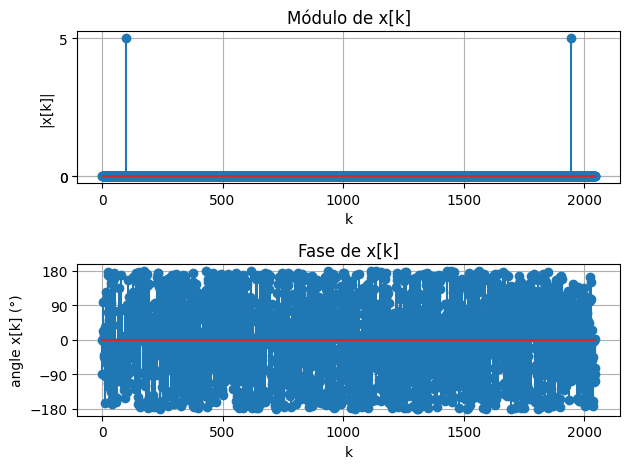

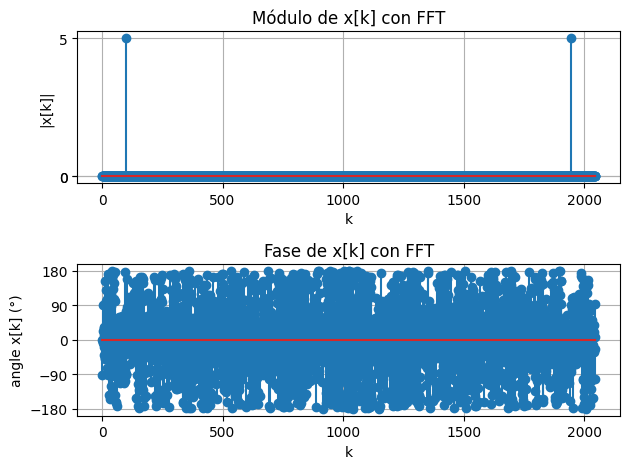

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Módulo y fase
modulo = np.abs(x_k) / N    # Normalizacion
fase = np.angle(x_k)
modulo_fft = np.abs(x_k_fft) / N
fase_fft = np.angle(x_k_fft)

# Gráficas my_DFT ########################################
plt.figure()

# Módulo
plt.subplot(2, 1, 1)
plt.stem(modulo)
plt.title("Módulo de x[k]")
plt.yticks([min(modulo_fft.flatten()), 0, max(modulo_fft.flatten())])

plt.xlabel("k")
plt.ylabel("|x[k]|")
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.title("Fase de x[k]")
plt.stem( np.rad2deg(fase))
plt.xlabel("k")
plt.ylabel("angle x[k] (°)")
plt.yticks([-180, -90, 0, 90, 180])
plt.grid()

plt.tight_layout()
plt.show()


# Gráficas FFT ########################################
plt.figure()

# Módulo
plt.subplot(2, 1, 1)
plt.stem(modulo_fft)
plt.yticks([min(modulo_fft.flatten()), 0, max(modulo_fft.flatten())])
plt.title("Módulo de x[k] con FFT")
plt.xlabel("k")
plt.ylabel("|x[k]|")
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.title("Fase de x[k] con FFT")
plt.stem( np.rad2deg(fase_fft))
plt.xlabel("k")
plt.ylabel("angle x[k] (°)")
plt.yticks([-180, -90, 0, 90, 180])
plt.grid()

plt.tight_layout()
plt.show()

# Otras pruebas

Se realiza lo mismo con otras funciones

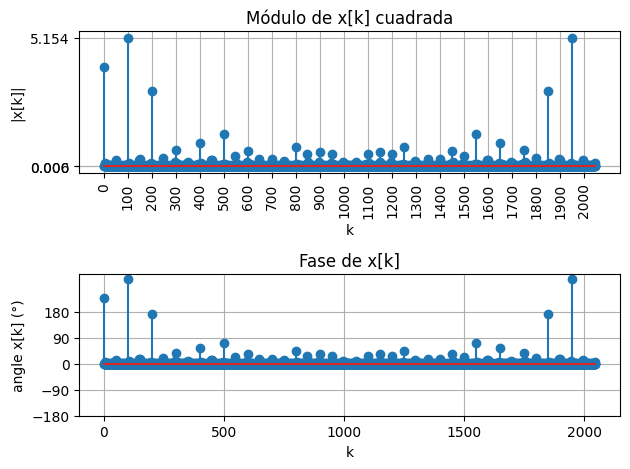

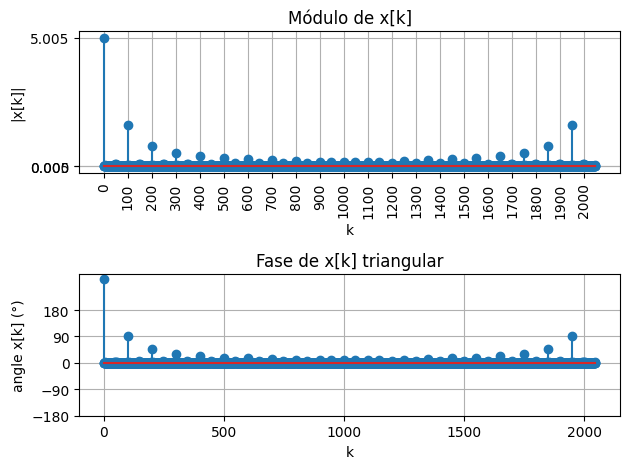

In [96]:
import numpy as np
import matplotlib.pyplot as plt


##### Variables
vmax = 10   # Vpico
freq = 100  # Freq
ph = 0      # Fase inicial
N = 2048    # Cant Muestras
fs = 2048   # Freq muestreo
duty = .7

##### Funcion
x1, _ = mi_funcion_cuadrada(vmax, ff=freq, duty=duty, nn=N, fs=fs)
x2, _ = mi_funcion_triangular(vmax, ff=freq, nn=N, fs=fs)

##### Calculo de FFT
x_k1 = my_DFT(x1)
x_k2 = my_DFT(x2)


# Módulo y fase
abs1 = np.abs(x_k1) / N    # Normalizacion
ang1 = np.angle(x_k1)
abs2 = np.abs(x_k2) / N
ang2 = np.angle(x_k2)

# Gráficas my_DFT ########################################
x_labels = np.arange(stop=N, step=freq)
plt.figure()

# Módulo
plt.subplot(2, 1, 1)
plt.stem(abs1)
plt.title("Módulo de x[k] cuadrada")
plt.yticks([min(abs1.flatten()), 0, max(abs1.flatten())])
plt.xticks(x_labels, rotation='vertical')

plt.xlabel("k")
plt.ylabel("|x[k]|")
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.title("Fase de x[k]")
plt.stem( np.rad2deg(abs1))
plt.xlabel("k")
plt.ylabel("angle x[k] (°)")
plt.yticks([-180, -90, 0, 90, 180])
plt.grid()

plt.tight_layout()
plt.show()

# Gráficas my_DFT ########################################
plt.figure()

# Módulo
plt.subplot(2, 1, 1)
plt.stem(abs2)
plt.title("Módulo de x[k]")
plt.yticks([min(abs2.flatten()), 0, max(abs2.flatten())])
plt.xticks(x_labels, rotation='vertical')

plt.xlabel("k")
plt.ylabel("|x[k]|")
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.title("Fase de x[k] triangular")
plt.stem( np.rad2deg(abs2))
plt.xlabel("k")
plt.ylabel("angle x[k] (°)")
plt.yticks([-180, -90, 0, 90, 180])
plt.grid()

plt.tight_layout()
plt.show()